# Fama-MacBeth Cross-Sectional Regression — ESG Premium / Greenium

**Objectif.** Tester si la caractéristique ESG est *priced* dans la cross-section des rendements actions, en contrôlant pour les 5 facteurs Fama-French via leurs proxies firme-level.

---

## Méthodologie en deux étapes

En cross-section, on **ne peut pas** mettre les facteurs FF (Mkt-RF, SMB, HML, RMW, CMA) directement comme régresseurs : ils sont identiques pour toutes les firmes à une date $t$ donnée → colinéarité parfaite avec la constante. On remplace chaque facteur par une variable spécifique à la firme :

| Facteur FF (série temporelle) | Variable firme (cross-section)            | Type |
|---|---|---|
| **Mkt-RF** | $\hat\beta^{MKT}_{i,t}$ — sensibilité au marché | **estimé** (rolling time-series) |
| **SMB**    | $\log(\text{Mcap}_{i,t})$                       | observé |
| **HML**    | Book-to-Market                                    | observé |
| **RMW**    | Operating Profitability                           | observé |
| **CMA**    | Asset growth (Investment)                         | observé |

**Le facteur marché est un cas spécial** : sa contrepartie firme n'est pas observable directement, c'est le **bêta de marché** $\beta^{MKT}_i$, qui doit être **estimé** dans une régression time-series préalable.

**Étape 1 (par firme, time-series).** Pour chaque firme $i$ et chaque mois $t$, sur une fenêtre glissante des 36 mois précédents :

$$R^{ex}_{i,\tau} = \alpha_i + \beta^{MKT}_{i,t} (R^{MKT}_\tau - R^f_\tau) + u_{i,\tau}, \quad \tau \in [t-35, t-1]$$

**Étape 2 (par date, cross-section).** À chaque mois $t$ :

$$R^{ex}_{i,t} = \gamma_{0,t} + \gamma_{MKT,t}\hat\beta^{MKT}_{i,t} + \gamma_{ESG,t} ESG_{i,t} + \gamma_{size,t}\log\text{Mcap}_{i,t} + \gamma_{BM,t} BM_{i,t} + \gamma_{OP,t} OP_{i,t} + \gamma_{INV,t} INV_{i,t} + \varepsilon_{i,t}$$

Puis : moyenne temporelle des $\gamma_t$, t-stat avec correction Newey-West.

**Interprétation $\hat\gamma_{ESG}$ :**
- $< 0$ et significatif → **greenium**
- $> 0$ et significatif → **ESG premium**
- $\approx 0$ → ESG non-priced


In [105]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10


## 1. Paramètres & chargement

In [106]:
# === MODIFY THESE PATHS TO YOUR LOCAL FILES ===
ESG_DATA_PATH    = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/price_esg/ESG_Panel_With_Closing_Price.xlsx"
FF_FACTORS_PATH  = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/fama_french_factors/5_factors ff_US.csv"
MCAP_PATH        = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/fama_french_factors/SP500_Mcap_Panel.xlsx"
ACCOUNTING_PATH  = "C:/Users/anton/OneDrive/Bureau/Edhec course/Master 2/Research Thesis/Data-Analysis/Data/fama_french_factors/SP500_Panel_Data_Fama_Factors.xlsx"

# === Estimation parameters ===
BETA_WINDOW   = 36   # rolling window in months for market beta (36 or 60 are standard)
BETA_MIN_OBS  = 24   # minimum observations within the window to compute a beta
NW_LAGS       = 6    # Newey-West lags for FM standard errors on the time series of gammas


In [107]:
# Load ESG panel and build monthly returns
data = pd.read_excel(ESG_DATA_PATH, sheet_name="Panel Data")
data["Date"] = pd.to_datetime(data["Date"])
data["Closing_Price"] = pd.to_numeric(data["Closing_Price"], errors="coerce")
data = data.dropna(subset=["Closing_Price", "ESG"]).copy()

data = data.sort_values(["Ticker", "Date"])
data["Return"] = data.groupby("Ticker")["Closing_Price"].pct_change()

# Align all dates to month-start for clean merges
data["Date"] = data["Date"].values.astype("datetime64[M]")

print(f"ESG panel: {data.shape[0]:,} obs | {data['Ticker'].nunique()} tickers | "
      f"{data['Date'].min().date()} → {data['Date'].max().date()}")


ESG panel: 52,825 obs | 404 tickers | 2015-01-01 → 2025-12-01


In [108]:
# Load Fama-French 5 factors (we need Mkt-RF and RF)
ff = pd.read_csv(FF_FACTORS_PATH, skiprows=4)
ff.columns = ['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
ff['Date'] = ff['Date'].astype(str).str.strip()
ff = ff[ff['Date'].str.len() == 6].copy()
ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m').values.astype("datetime64[M]")
for c in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
    ff[c] = pd.to_numeric(ff[c], errors='coerce') / 100.0  # to decimal

# Merge RF and Mkt-RF into the firm panel
data = data.merge(ff[['Date', 'RF', 'Mkt-RF']], on='Date', how='left')
data['ExRet'] = data['Return'] - data['RF']

print(f"Excess returns computed for {data['ExRet'].notna().sum():,} obs")
data[['Ticker','Date','Return','RF','ExRet','Mkt-RF']].tail()


Excess returns computed for 52,421 obs


,Ticker,Date,Return,RF,ExRet,Mkt-RF
52820,ZTS,2025-08-01,0.049117,0.0038,0.045317,0.0185
52821,ZTS,2025-09-01,-0.067310,0.0033,-0.070610,0.0339
52822,ZTS,2025-10-01,0.001764,0.0037,-0.001936,0.0196
52823,ZTS,2025-11-01,-0.115185,0.0030,-0.118185,-0.0013
52824,ZTS,2025-12-01,-0.030577,0.0034,-0.033977,-0.0036


DISTRIBUTION OF MONTHLY RETURNS — simple vs log
                  Simple returns  Log returns
Mean                      0.0098       0.0063
Std                       0.0839       0.0843
Skewness                  0.4877      -0.8513
Excess kurtosis          12.4544      12.1236
Jarque-Bera stat     340806.9958  327301.7010
JB p-value                0.0000       0.0000


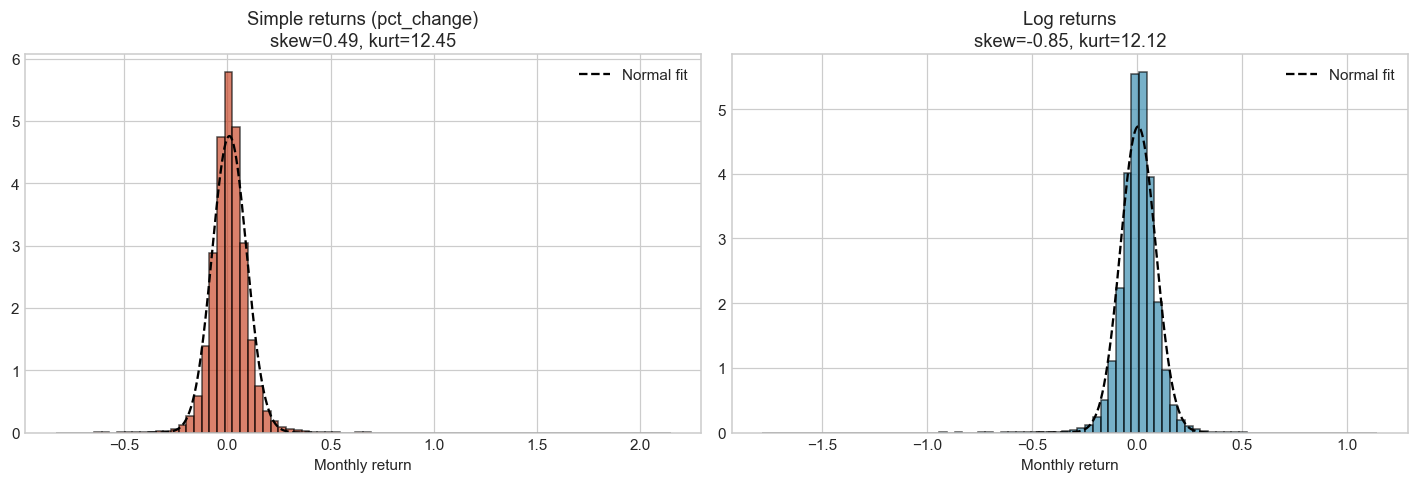


INTERPRETATION
--------------
- Simple returns are bounded below at -1 but unbounded above → asymmetric (right-skewed).
- Log returns are symmetric and closer to normal — a key OLS assumption.
- If JB p-value << 0.05 for simple but log returns are visibly closer to normal,
  this justifies log-transforming for the time-series beta regression in Step 1.
- For Step 2 (cross-sectional FM) the choice matters less, but consistency is cleaner.



In [109]:
# === DIAGNOSTIC: Why log-returns? Distribution of monthly price changes ===
# Compute both versions for comparison
data_diag = data.dropna(subset=["Closing_Price"]).sort_values(["Ticker", "Date"]).copy()
data_diag["SimpleRet"] = data_diag.groupby("Ticker")["Closing_Price"].pct_change()
data_diag["LogRet"]    = (data_diag.groupby("Ticker")["Closing_Price"]
                                   .transform(lambda s: np.log(s / s.shift(1))))

simple = data_diag["SimpleRet"].dropna()
logret = data_diag["LogRet"].dropna()

# Jarque-Bera test for normality (H0: normal)
jb_simple = stats.jarque_bera(simple)
jb_log    = stats.jarque_bera(logret)

print("="*78)
print("DISTRIBUTION OF MONTHLY RETURNS — simple vs log")
print("="*78)
diag_tbl = pd.DataFrame({
    'Simple returns':  [simple.mean(), simple.std(), simple.skew(),
                        simple.kurtosis(), jb_simple.statistic, jb_simple.pvalue],
    'Log returns':     [logret.mean(), logret.std(), logret.skew(),
                        logret.kurtosis(), jb_log.statistic, jb_log.pvalue]
}, index=['Mean','Std','Skewness','Excess kurtosis','Jarque-Bera stat','JB p-value'])
print(diag_tbl.round(4).to_string())

# Plot the two distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, series, name, col in [(axes[0], simple, 'Simple returns (pct_change)', '#C73E1D'),
                              (axes[1], logret, 'Log returns', '#2E86AB')]:
    ax.hist(series, bins=80, color=col, alpha=0.65, edgecolor='black', density=True)
    # Overlay a normal pdf with the same mean/std for visual reference
    xs = np.linspace(series.quantile(0.001), series.quantile(0.999), 300)
    ax.plot(xs, stats.norm.pdf(xs, series.mean(), series.std()),
            'k--', linewidth=1.5, label='Normal fit')
    ax.set_title(f"{name}\nskew={series.skew():.2f}, kurt={series.kurtosis():.2f}")
    ax.set_xlabel('Monthly return'); ax.legend()
plt.tight_layout()
plt.savefig('FM_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
INTERPRETATION
--------------
- Simple returns are bounded below at -1 but unbounded above → asymmetric (right-skewed).
- Log returns are symmetric and closer to normal — a key OLS assumption.
- If JB p-value << 0.05 for simple but log returns are visibly closer to normal,
  this justifies log-transforming for the time-series beta regression in Step 1.
- For Step 2 (cross-sectional FM) the choice matters less, but consistency is cleaner.
""")

## 2. Étape 1 — Estimation des bêtas marché (rolling)

Pour chaque firme et chaque mois, on calcule :

$$\hat\beta^{MKT}_{i,t} = \frac{\widehat{\text{Cov}}(R^{ex}_i, \text{Mkt-RF})_t}{\widehat{\text{Var}}(\text{Mkt-RF})_t}$$

estimé sur la **fenêtre glissante** $[t-35, t-1]$ (36 mois, n'utilise QUE de l'information passée → no look-ahead).

Cette formule est mathématiquement équivalente à l'OLS univarié avec constante, mais beaucoup plus rapide en vectorisé qu'une boucle de régressions.


In [110]:
def rolling_beta(group, window=BETA_WINDOW, min_obs=BETA_MIN_OBS):
    """
    Rolling market beta for one firm: Cov(ExRet, Mkt-RF) / Var(Mkt-RF).
    Uses .shift(1) so beta at month t uses data up to month t-1 (no look-ahead).
    """
    y = group['ExRet']
    x = group['Mkt-RF']
    cov_xy = y.rolling(window, min_periods=min_obs).cov(x)
    var_x  = x.rolling(window, min_periods=min_obs).var()
    beta   = cov_xy / var_x
    return beta.shift(1)  # use t-1 info to predict t

print(f"Computing rolling market betas (window = {BETA_WINDOW} months)...")
data = data.sort_values(['Ticker', 'Date'])
data['Beta_MKT'] = (
    data.groupby('Ticker', group_keys=False).apply(rolling_beta)
)

print(f"Beta_MKT computed for {data['Beta_MKT'].notna().sum():,} obs")
print(f"\nBeta_MKT distribution:")
print(data['Beta_MKT'].describe().round(3))


Computing rolling market betas (window = 36 months)...
Beta_MKT computed for 42,748 obs

Beta_MKT distribution:
count    42748.000
mean         0.867
std          0.510
min         -0.885
25%          0.530
50%          0.859
75%          1.159
max          5.467
Name: Beta_MKT, dtype: float64


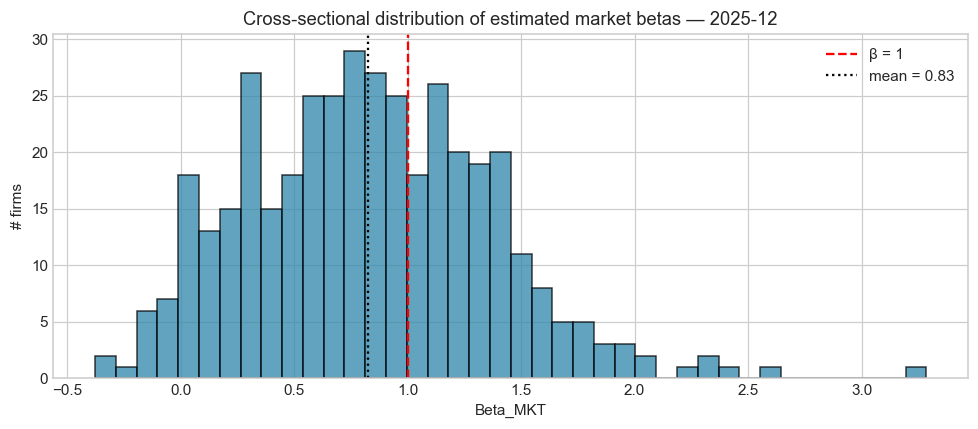

In [ ]:
# Sanity check: cross-sectional dispersion of estimated market betas at one date
sample_date = data.dropna(subset=['Beta_MKT'])['Date'].max()
sample = data[data['Date'] == sample_date]['Beta_MKT'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sample, bins=40, color='#2E86AB', alpha=0.75, edgecolor='black')
ax.axvline(1.0, color='red',   linestyle='--', label='β = 1')
ax.axvline(sample.mean(), color='black', linestyle=':',
           label=f'mean = {sample.mean():.2f}')
ax.set_title(f'Cross-sectional distribution of estimated market betas — '
             f'{pd.Timestamp(sample_date).strftime("%Y-%m")}')
ax.set_xlabel('Beta_MKT'); ax.set_ylabel('# firms')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Construction des autres caractéristiques firme

| Caractéristique | Variable | Construction | Proxy de |
|---|---|---|---|
| Size           | `log_Mcap` | $\log(\text{Mcap}_{i,t})$ | SMB |
| Value          | `BM`       | Equity (lagué 1y) / Mcap | HML |
| Profitability  | `OP`       | EBIT (lagué 1y) / Equity (lagué 1y) | RMW |
| Investment     | `INV`      | $\Delta\text{Assets}$ (lagué 1y) | CMA |
| ESG            | `ESG`      | score brut | variable d'intérêt |

Variables comptables **laguées d'un an** pour éviter le look-ahead bias.


In [112]:
# Market cap → log size
mcap = pd.read_excel(MCAP_PATH)
mcap["Date"] = pd.to_datetime(mcap["Date"]).values.astype("datetime64[M]")
mcap["Mcap (€M)"] = pd.to_numeric(mcap["Mcap (€M)"], errors="coerce")
mcap = mcap.dropna(subset=["Mcap (€M)"])

data = data.merge(mcap[["Ticker", "Date", "Mcap (€M)"]],
                  on=["Ticker", "Date"], how="left")
data["log_Mcap"] = np.log(data["Mcap (€M)"])

print(f"After Mcap merge: {data['log_Mcap'].notna().sum():,} obs with size")


After Mcap merge: 52,044 obs with size


In [113]:
# Annual accounting → BM, OP, INV, lagged 1 year
acc = pd.read_excel(ACCOUNTING_PATH)
for c in ["Assets (€000)", "Equity (€000)", "EBIT (€000)"]:
    acc[c] = pd.to_numeric(acc[c], errors="coerce")
acc = acc.rename(columns={"Assets (€000)": "Assets",
                          "Equity (€000)": "Equity",
                          "EBIT (€000)":   "EBIT"})
acc = acc.sort_values(["Ticker", "Year"])

acc["OP"]  = acc["EBIT"] / acc["Equity"].replace(0, np.nan)
acc["INV"] = acc.groupby("Ticker")["Assets"].pct_change()

# Lag by 1 year: financials of fiscal year Y are matched to all months of year Y+1
acc["MatchYear"] = acc["Year"] + 1
acc_lag = acc[["Ticker", "MatchYear", "Equity", "OP", "INV"]].rename(
    columns={"MatchYear": "Year"})

data["Year"] = data["Date"].dt.year
data = data.merge(acc_lag, on=["Ticker", "Year"], how="left")

# Book-to-market: book equity (lagged, €000 → €M) / market cap (€M)
data["BM"] = (data["Equity"] / 1000.0) / data["Mcap (€M)"]

# Winsorize regressors per date at 1%/99% (critical for FM: one outlier can
# dominate one month's coefficient)
def winsorize_xs(s, lo=0.01, hi=0.99):
    q_lo, q_hi = s.quantile(lo), s.quantile(hi)
    return s.clip(q_lo, q_hi)

for c in ["BM", "OP", "INV", "log_Mcap", "Beta_MKT"]:
    data[c] = data.groupby("Date")[c].transform(winsorize_xs)

print("Coverage after merging all characteristics:")
print(data[["ExRet", "Beta_MKT", "ESG", "log_Mcap", "BM", "OP", "INV"]]
      .notna().mean().round(3))

Coverage after merging all characteristics:
ExRet       0.992
Beta_MKT    0.809
ESG         1.000
log_Mcap    0.985
BM          0.895
OP          0.857
INV         0.817
dtype: float64


In [114]:
# Vérification : le BM doit varier mois par mois pour une même firme/année
check = (data.dropna(subset=["BM"])
             .groupby(["Ticker", "Year"])["BM"]
             .nunique()
             .describe())
print("Nb de valeurs distinctes de BM par (Ticker, Year) :")
print(check)
print("\nSi le 'mean' est proche de 12 → BM est bien mensuel ✅")
print("Si le 'mean' est 1 → BM est figé annuellement ❌")

Nb de valeurs distinctes de BM par (Ticker, Year) :
count    3979.000000
mean       11.875597
std         0.500231
min         1.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        12.000000
Name: BM, dtype: float64

Si le 'mean' est proche de 12 → BM est bien mensuel ✅
Si le 'mean' est 1 → BM est figé annuellement ❌


In [115]:
# === MOMENTUM FACTOR (Jegadeesh-Titman 1993, standard "12-2" formulation) ===
# MOM_{i,t} = cumulative return from t-12 to t-2 (i.e. skip the most recent month
# to avoid the short-term reversal effect documented by Jegadeesh 1990).
data = data.sort_values(["Ticker", "Date"])

def momentum_12_2(group):
    r = group["Return"]
    # log-cumulative return over months [t-12, t-2]: skip t-1 (reversal), use 11 months
    log_r = np.log1p(r)
    cum = log_r.rolling(window=11, min_periods=8).sum()
    # shift by 1 so MOM at month t uses returns up to t-2 (no look-ahead)
    return cum.shift(1)

data["MOM"] = (data.groupby("Ticker", group_keys=False).apply(momentum_12_2))

# Winsorize cross-sectionally just like the other regressors
data["MOM"] = data.groupby("Date")["MOM"].transform(winsorize_xs)

print(f"MOM computed for {data['MOM'].notna().sum():,} obs")
print(f"\nMOM cross-sectional summary at the latest date:")
last_date = data.dropna(subset=['MOM'])['Date'].max()
print(data.loc[data['Date']==last_date, 'MOM'].describe().round(3))

MOM computed for 49,196 obs

MOM cross-sectional summary at the latest date:
count    399.000
mean      -0.045
std        0.255
min       -0.766
25%       -0.195
50%       -0.044
75%        0.093
max        0.708
Name: MOM, dtype: float64


## 4. Étape 2 — Régression Fama-MacBeth

À chaque date :
1. on prend toutes les firmes ayant des observations valides,
2. on régresse $R^{ex}_{i,t}$ sur Beta_MKT + caractéristiques,
3. on stocke les coefficients $\hat\gamma_t$ et les diagnostics.

Ensuite : moyenne temporelle des $\gamma_t$, t-stat avec correction Newey-West.


In [ ]:
def fama_macbeth(panel, y_col, x_cols, date_col='Date', min_obs=30):
    """
    Run Fama-MacBeth cross-sectional regressions.

    Returns
    -------
    coefs : DataFrame (T x K)  -- gamma_t per date for each regressor
    diag  : DataFrame          -- per-date R2 and N
    """
    needed = [y_col] + x_cols
    df = panel.dropna(subset=needed).copy()

    coefs_rows, diag_rows = [], []
    for date, sub in df.groupby(date_col):
        if len(sub) < min_obs:
            continue
        X = sm.add_constant(sub[x_cols].values)
        y = sub[y_col].values
        res = sm.OLS(y, X).fit()
        coefs_rows.append({date_col: date,
                           **{n: c for n, c in zip(['const'] + x_cols, res.params)}})
        diag_rows.append({date_col: date, 'R2': res.rsquared, 'N': len(sub)})

    coefs = pd.DataFrame(coefs_rows).set_index(date_col).sort_index()
    diag  = pd.DataFrame(diag_rows).set_index(date_col).sort_index()
    return coefs, diag


def fm_summary(coefs, nw_lags=12):
    """Time-series summary of FM gammas with Newey-West t-stats."""
    rows = []
    for col in coefs.columns:
        s = coefs[col].dropna()
        mean = s.mean()
        nw = sm.OLS(s.values, np.ones(len(s))).fit(
            cov_type='HAC', cov_kwds={'maxlags': nw_lags})
        se   = nw.bse[0]
        tval = mean / se if se > 0 else np.nan
        pval = 2 * (1 - stats.t.cdf(abs(tval), df=len(s)-1))
        rows.append({'Variable': col, 'Mean (γ)': mean, 'NW SE': se,
                     't-stat': tval, 'p-value': pval, 'T (months)': len(s)})
    return pd.DataFrame(rows)

## 5. Résultats — quatre spécifications progressives

- **Spec 1** : ESG seul → effet brut.
- **Spec 2** : ESG + Beta_MKT → contrôle CAPM.
- **Spec 3** : ESG + Beta_MKT + log_Mcap → contrôle CAPM + size.
- **Spec 4** : modèle complet "FF5-like" (ESG + Beta_MKT + size + BM + OP + INV).

Si l'effet ESG survit dans Spec 4, c'est le résultat principal : l'ESG porte une information distincte des 5 facteurs FF.


In [117]:
coefs1, diag1 = fama_macbeth(data, 'ExRet', ['ESG'])
summary1 = fm_summary(coefs1, NW_LAGS)
print("="*80); print("SPEC 1 — Excess return on ESG only"); print("="*80)
print(summary1.to_string(index=False))
print(f"\nAvg cross-sec. R² : {diag1['R2'].mean():.4f}  |  Avg N : {diag1['N'].mean():.0f}")


SPEC 1 — Excess return on ESG only
Variable  Mean (γ)    NW SE    t-stat  p-value  T (months)
   const  0.012331 0.003101  3.976279 0.000116         131
     ESG -0.000088 0.000025 -3.544767 0.000547         131

Avg cross-sec. R² : 0.0041  |  Avg N : 400


In [118]:
coefs2, diag2 = fama_macbeth(data, 'ExRet', ['ESG', 'Beta_MKT'])
summary2 = fm_summary(coefs2, NW_LAGS)
print("="*80); print("SPEC 2 — Excess return on ESG + Beta_MKT (CAPM-like)"); print("="*80)
print(summary2.to_string(index=False))
print(f"\nAvg cross-sec. R² : {diag2['R2'].mean():.4f}  |  Avg N : {diag2['N'].mean():.0f}")


SPEC 2 — Excess return on ESG + Beta_MKT (CAPM-like)
Variable  Mean (γ)    NW SE    t-stat  p-value  T (months)
   const  0.003970 0.003813  1.041186 0.300158         107
     ESG -0.000081 0.000025 -3.297108 0.001330         107
Beta_MKT  0.008463 0.003621  2.337254 0.021305         107

Avg cross-sec. R² : 0.0717  |  Avg N : 400


In [119]:
coefs3, diag3 = fama_macbeth(data, 'ExRet', ['ESG', 'Beta_MKT', 'log_Mcap'])
summary3 = fm_summary(coefs3, NW_LAGS)
print("="*80); print("SPEC 3 — Excess return on ESG + Beta_MKT + log_Mcap"); print("="*80)
print(summary3.to_string(index=False))
print(f"\nAvg cross-sec. R² : {diag3['R2'].mean():.4f}  |  Avg N : {diag3['N'].mean():.0f}")


SPEC 3 — Excess return on ESG + Beta_MKT + log_Mcap
Variable  Mean (γ)    NW SE    t-stat  p-value  T (months)
   const  0.003534 0.004987  0.708585 0.480138         107
     ESG -0.000081 0.000024 -3.320208 0.001234         107
Beta_MKT  0.008509 0.003622  2.349184 0.020668         107
log_Mcap  0.000037 0.000176  0.211093 0.833220         107

Avg cross-sec. R² : 0.0757  |  Avg N : 396


In [120]:
coefs4, diag4 = fama_macbeth(
    data, 'ExRet', ['ESG', 'Beta_MKT', 'log_Mcap', 'BM', 'OP', 'INV'])
summary4 = fm_summary(coefs4, NW_LAGS)
print("="*80)
print("SPEC 4: ESG + Beta_MKT + size + BM + OP + INV (FF5-like)")
print("="*80)
print(summary4.to_string(index=False))
print(f"\nAvg cross-sec. R² : {diag4['R2'].mean():.4f}  |  Avg N : {diag4['N'].mean():.0f}")


SPEC 4: ESG + Beta_MKT + size + BM + OP + INV (FF5-like)
Variable  Mean (γ)    NW SE    t-stat  p-value  T (months)
   const  0.003924 0.004840  0.810715 0.419346         107
     ESG -0.000078 0.000024 -3.238547 0.001605         107
Beta_MKT  0.008739 0.003547  2.463777 0.015356         107
log_Mcap -0.000011 0.000198 -0.056819 0.954796         107
      BM  0.000005 0.000007  0.716927 0.474996         107
      OP  0.000057 0.000395  0.143646 0.886053         107
     INV  0.000031 0.000130  0.238910 0.811637         107

Avg cross-sec. R² : 0.0828  |  Avg N : 374


In [121]:
coefs5, diag5 = fama_macbeth(
    data, 'ExRet', ['ESG', 'Beta_MKT', 'log_Mcap', 'BM', 'OP', 'INV', 'MOM'])
summary5 = fm_summary(coefs5, NW_LAGS)
print("="*80)
print("SPEC 5: ESG + Beta_MKT + size + BM + OP + INV + MOM (FF5 + momentum)")
print("="*80)
print(summary5.to_string(index=False))
print(f"\nAvg cross-sec. R² : {diag5['R2'].mean():.4f}  |  Avg N : {diag5['N'].mean():.0f}")


SPEC 5: ESG + Beta_MKT + size + BM + OP + INV + MOM (FF5 + momentum)
Variable  Mean (γ)    NW SE    t-stat  p-value  T (months)
   const  0.003865 0.004761  0.811954 0.418637         107
     ESG -0.000077 0.000024 -3.196885 0.001831         107
Beta_MKT  0.008001 0.003532  2.265213 0.025533         107
log_Mcap -0.000026 0.000207 -0.125516 0.900353         107
      BM  0.000004 0.000006  0.693753 0.489354         107
      OP  0.000064 0.000374  0.170159 0.865210         107
     INV  0.000036 0.000121  0.298477 0.765924         107
     MOM  0.006432 0.004729  1.360096 0.176685         107

Avg cross-sec. R² : 0.1163  |  Avg N : 374


AVERAGE CROSS-SECTIONAL CORRELATION MATRIX (over all months)
            ESG  Beta_MKT  log_Mcap     BM     OP    INV    MOM
ESG       1.000    -0.046    -0.030 -0.010 -0.008 -0.009 -0.048
Beta_MKT -0.046     1.000    -0.044  0.028  0.016  0.003  0.081
log_Mcap -0.030    -0.044     1.000 -0.409  0.020 -0.014 -0.012
BM       -0.010     0.028    -0.409  1.000 -0.057  0.094  0.001
OP       -0.008     0.016     0.020 -0.057  1.000 -0.040  0.017
INV      -0.009     0.003    -0.014  0.094 -0.040  1.000 -0.006
MOM      -0.048     0.081    -0.012  0.001  0.017 -0.006  1.000


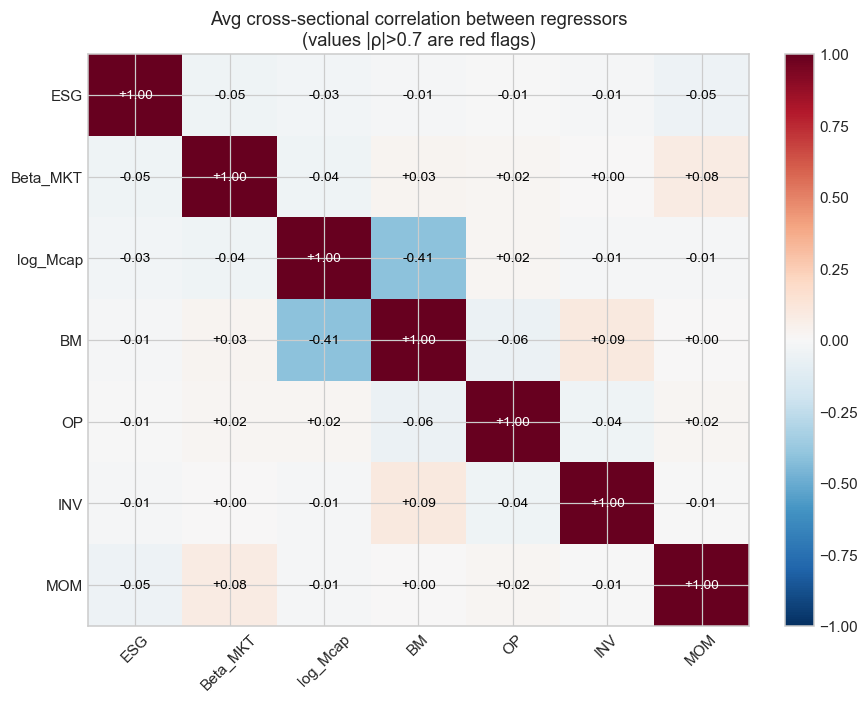


VARIANCE INFLATION FACTORS (pooled panel)
Variable       VIF
   const 54.759936
     ESG  1.003842
Beta_MKT  1.009127
log_Mcap  1.016961
      BM  1.010936
      OP  1.001759
     INV  1.000652
     MOM  1.007142

RULE OF THUMB
-------------
- VIF < 5  → no concern
- 5 ≤ VIF < 10 → moderate collinearity, watch out
- VIF ≥ 10 → severe — coefficients become unstable and standard errors inflate.
            Consider dropping the variable or merging it with a correlated one.



In [131]:
# === MULTICOLLINEARITY DIAGNOSTICS ===
# Two complementary tests:
#  1) Cross-sectional Pearson correlations between regressors (averaged over dates)
#  2) Variance Inflation Factors (VIF) on the pooled panel
from statsmodels.stats.outliers_influence import variance_inflation_factor

regressors_full = ['ESG', 'Beta_MKT', 'log_Mcap', 'BM', 'OP', 'INV', 'MOM']

# --- 1. Average cross-sectional correlation matrix ---
# We compute the corr matrix at each date, then average — this is the relevant
# notion for FM (each regression is run cross-sectionally).
def xs_corr(sub):
    return sub[regressors_full].corr()

corr_by_date = (data.dropna(subset=regressors_full)
                    .groupby('Date').apply(xs_corr))
avg_corr = corr_by_date.groupby(level=1).mean().loc[regressors_full, regressors_full]

print("="*78)
print("AVERAGE CROSS-SECTIONAL CORRELATION MATRIX (over all months)")
print("="*78)
print(avg_corr.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(avg_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(regressors_full))); ax.set_xticklabels(regressors_full, rotation=45)
ax.set_yticks(range(len(regressors_full))); ax.set_yticklabels(regressors_full)
for i in range(len(regressors_full)):
    for j in range(len(regressors_full)):
        v = avg_corr.values[i, j]
        ax.text(j, i, f"{v:+.2f}", ha='center', va='center',
                color='white' if abs(v) > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Avg cross-sectional correlation between regressors\n(values |ρ|>0.7 are red flags)')
plt.tight_layout()
plt.savefig('FM_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2. VIF on the pooled (winsorized) panel ---
panel = data.dropna(subset=regressors_full)[regressors_full].copy()
X_vif = sm.add_constant(panel.values)
vif = pd.DataFrame({
    'Variable': ['const'] + regressors_full,
    'VIF':      [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
})
print("\n" + "="*78); print("VARIANCE INFLATION FACTORS (pooled panel)"); print("="*78)
print(vif.to_string(index=False))
print("""
RULE OF THUMB
-------------
- VIF < 5  → no concern
- 5 ≤ VIF < 10 → moderate collinearity, watch out
- VIF ≥ 10 → severe — coefficients become unstable and standard errors inflate.
            Consider dropping the variable or merging it with a correlated one.
""")

In [122]:
def fmt(s, var):
    if var not in s['Variable'].values:
        return ''
    row = s[s['Variable'] == var].iloc[0]
    if   row['p-value'] < 0.01: stars = '***'
    elif row['p-value'] < 0.05: stars = '**'
    elif row['p-value'] < 0.10: stars = '*'
    else:                       stars = ''
    return f"{row['Mean (γ)']:+.5f}{stars} ({row['t-stat']:+.2f})"

variables = ['const', 'ESG', 'Beta_MKT', 'log_Mcap', 'BM', 'OP', 'INV', 'MOM']
table = pd.DataFrame(index=variables, columns=['Spec 1', 'Spec 2', 'Spec 3', 'Spec 4', 'Spec 5'])
for var in variables:
    table.loc[var, 'Spec 1'] = fmt(summary1, var)
    table.loc[var, 'Spec 2'] = fmt(summary2, var)
    table.loc[var, 'Spec 3'] = fmt(summary3, var)
    table.loc[var, 'Spec 4'] = fmt(summary4, var)
    table.loc[var, 'Spec 5'] = fmt(summary5, var)

table.loc['Avg R²'] = [f"{d['R2'].mean():.3f}" for d in [diag1, diag2, diag3, diag4, diag5]]
table.loc['Avg N']  = [f"{d['N'].mean():.0f}"  for d in [diag1, diag2, diag3, diag4, diag5]]

print("="*90)
print("FAMA-MACBETH COMPARISON — γ̄ (NW t-stat). Stars: *** 1%, ** 5%, * 10%.")
print("="*90)
print(table.fillna('').to_string())


FAMA-MACBETH COMPARISON — γ̄ (NW t-stat). Stars: *** 1%, ** 5%, * 10%.
                       Spec 1               Spec 2               Spec 3               Spec 4               Spec 5
const     +0.01233*** (+3.98)     +0.00397 (+1.04)     +0.00353 (+0.71)     +0.00392 (+0.81)     +0.00387 (+0.81)
ESG       -0.00009*** (-3.54)  -0.00008*** (-3.30)  -0.00008*** (-3.32)  -0.00008*** (-3.24)  -0.00008*** (-3.20)
Beta_MKT                        +0.00846** (+2.34)   +0.00851** (+2.35)   +0.00874** (+2.46)   +0.00800** (+2.27)
log_Mcap                                               +0.00004 (+0.21)     -0.00001 (-0.06)     -0.00003 (-0.13)
BM                                                                          +0.00000 (+0.72)     +0.00000 (+0.69)
OP                                                                          +0.00006 (+0.14)     +0.00006 (+0.17)
INV                                                                         +0.00003 (+0.24)     +0.00004 (+0.30)
MOM              

AUTOCORRELATION OF γ_t — justifies Newey-West and the choice of lag length
Variable  AR(1) ρ  AR(6) ρ  AR(12) ρ  Durbin-Watson  Ljung-Box(6) p  Ljung-Box(12) p
   const   0.0894  -0.2342   -0.0661         1.7842          0.0113           0.0162
     ESG  -0.0218  -0.1378   -0.1226         1.8922          0.6853           0.6014
Beta_MKT  -0.0967   0.1726   -0.0122         2.1113          0.3917           0.4031
log_Mcap  -0.0278  -0.1891   -0.0312         2.0474          0.4236           0.4482
      BM   0.1112   0.0407   -0.1649         1.7668          0.5671           0.2567
      OP   0.2398   0.0877    0.1208         1.5138          0.2228           0.1704
     INV   0.0581   0.0610   -0.1222         1.8717          0.2912           0.2190

HOW TO READ
-----------
- AR(1) close to 0 and Ljung-Box p > 0.05 → γ_t is essentially white noise,
  Newey-West is just a safety net.
- AR(1) > 0.2 OR Ljung-Box p < 0.05 → significant persistence in γ_t.
  This is exactly why we use Newey-West

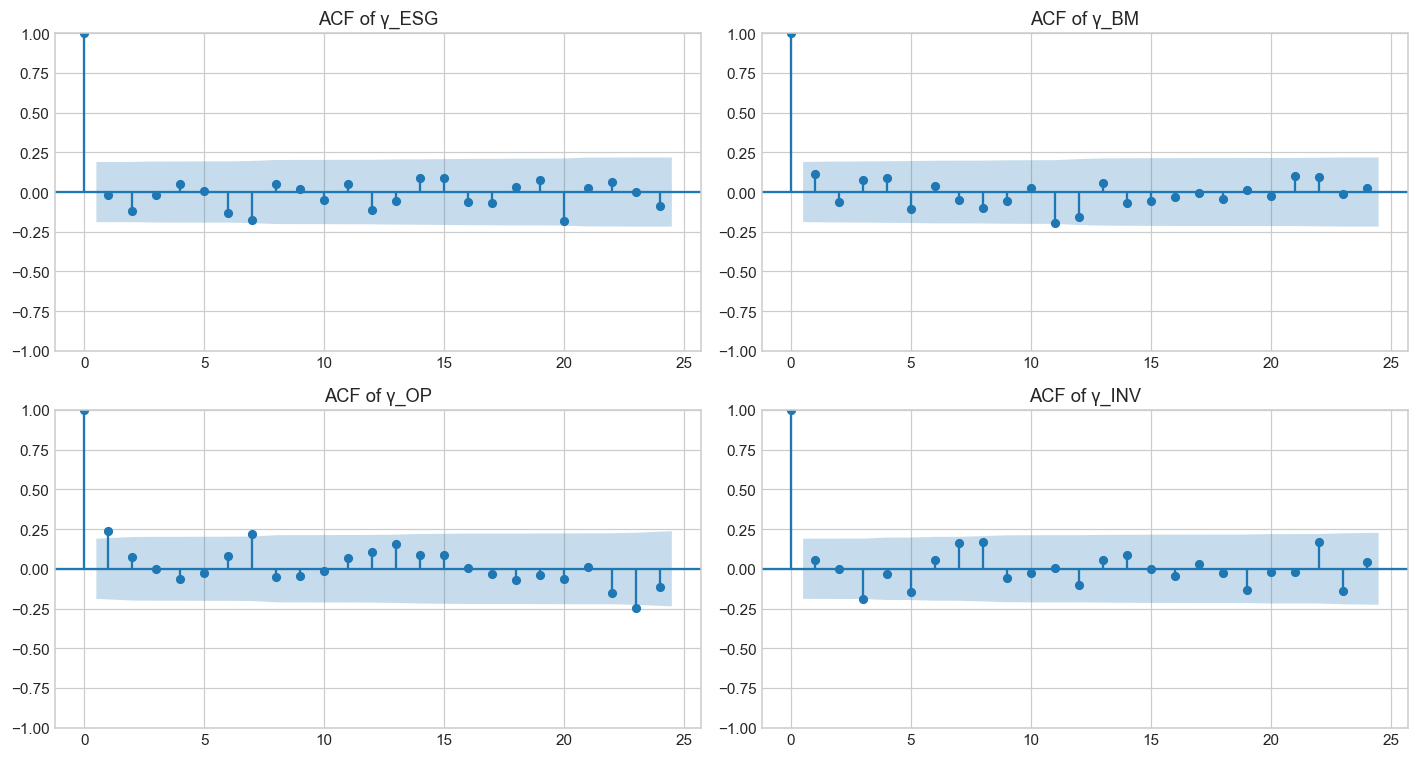


Sensitivity of t-stat(γ_ESG) to the choice of NW_LAGS:
            NW lags       SE    t-stat
OLS (no correction) 0.000027 -2.880558
                  3 0.000025 -3.114632
                  6 0.000024 -3.238547
                 12 0.000020 -3.945836
                 18 0.000017 -4.504822
                 24 0.000015 -5.085863


In [132]:
# === AUTOCORRELATION DIAGNOSTICS ON THE TIME-SERIES OF γ_t ===
# The whole point of Newey-West is to correct standard errors for autocorrelation
# in the gamma time-series. If gammas are NOT autocorrelated, plain OLS SE = NW SE.
# If they ARE, plain OLS underestimates the variance and t-stats are inflated.
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

print("="*90)
print("AUTOCORRELATION OF γ_t — justifies Newey-West and the choice of lag length")
print("="*90)

rows = []
for col in coefs4.columns:
    s = coefs4[col].dropna()
    # Durbin-Watson: ~2 means no AR(1), <2 positive AR, >2 negative AR
    dw = durbin_watson(s.values)
    # Ljung-Box for higher-order autocorrelation up to 12 lags
    lb = acorr_ljungbox(s, lags=[6, 12], return_df=True)
    rows.append({
        'Variable': col,
        'AR(1) ρ':  s.autocorr(lag=1),
        'AR(6) ρ':  s.autocorr(lag=6),
        'AR(12) ρ': s.autocorr(lag=12),
        'Durbin-Watson':    dw,
        'Ljung-Box(6) p':   lb.loc[6,  'lb_pvalue'],
        'Ljung-Box(12) p':  lb.loc[12, 'lb_pvalue'],
    })
diag_ac = pd.DataFrame(rows)
print(diag_ac.round(4).to_string(index=False))

print("""
HOW TO READ
-----------
- AR(1) close to 0 and Ljung-Box p > 0.05 → γ_t is essentially white noise,
  Newey-West is just a safety net.
- AR(1) > 0.2 OR Ljung-Box p < 0.05 → significant persistence in γ_t.
  This is exactly why we use Newey-West, AND it justifies setting NW_LAGS
  large enough to cover the persistence horizon.
- Variables with quasi-annual update frequency (BM, OP, INV) typically show
  high AR(1) — that's the structural reason to set NW_LAGS = 12 for them.
""")

# Visual: ACF of the four most interesting series
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, var in zip(axes.ravel(), ['ESG', 'BM', 'OP', 'INV']):
    if var in coefs4.columns:
        plot_acf(coefs4[var].dropna(), lags=24, ax=ax, alpha=0.05)
        ax.set_title(f'ACF of γ_{var}')
plt.tight_layout()
plt.savefig('FM_gamma_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

# Sensitivity: how does the t-stat of γ_ESG change with NW_LAGS?
print("\nSensitivity of t-stat(γ_ESG) to the choice of NW_LAGS:")
sens_rows = []
s_esg = coefs4['ESG'].dropna()
for L in [0, 3, 6, 12, 18, 24]:
    nw = sm.OLS(s_esg.values, np.ones(len(s_esg))).fit(
        cov_type='HAC', cov_kwds={'maxlags': max(L,1)})
    se = nw.bse[0]
    sens_rows.append({'NW lags': L if L>0 else 'OLS (no correction)',
                      'SE': se, 't-stat': s_esg.mean()/se})
print(pd.DataFrame(sens_rows).to_string(index=False))

## 6. Évolution temporelle du coefficient ESG (Spec 4)

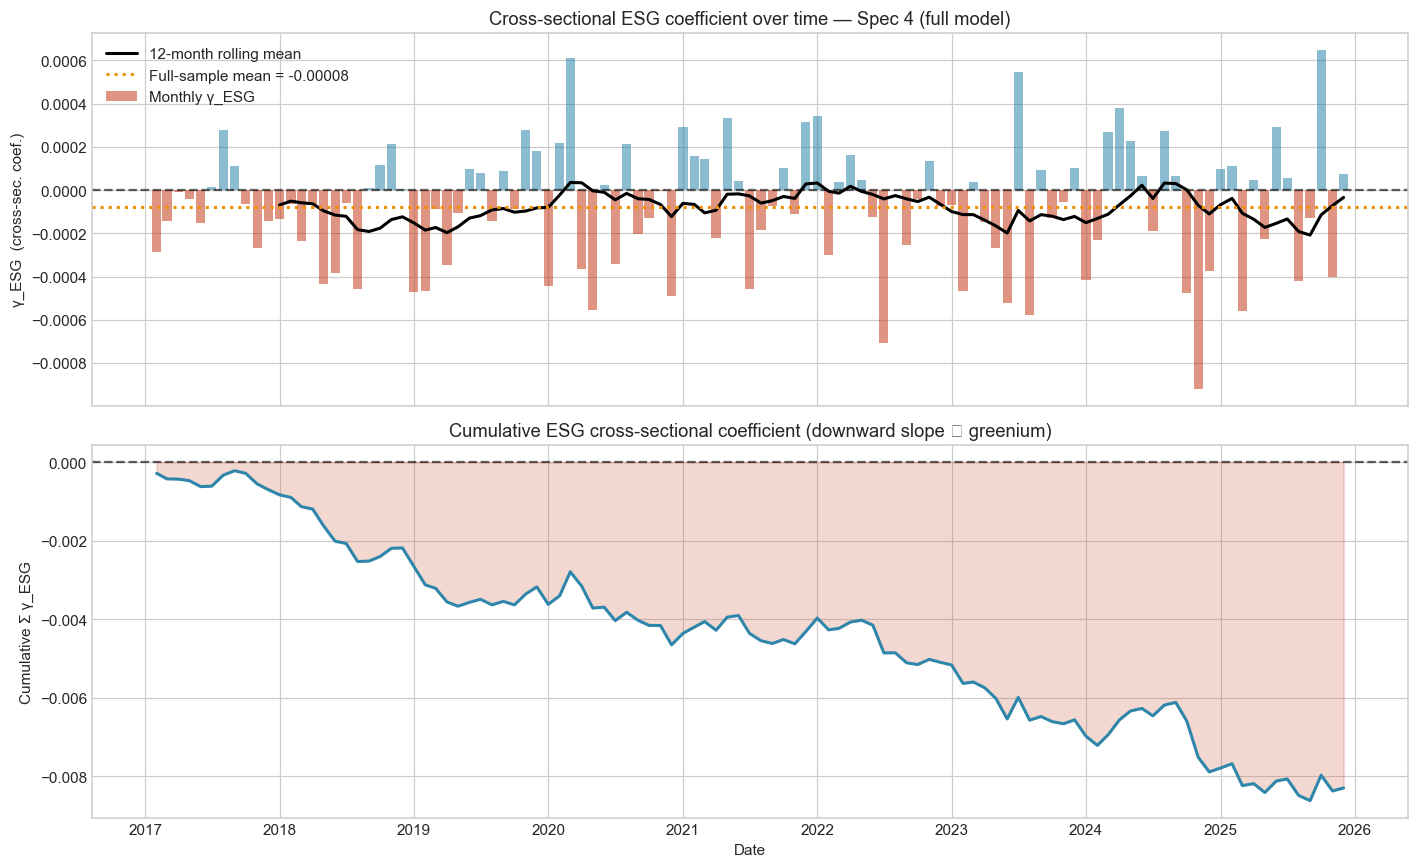

In [123]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

g = coefs4['ESG']
roll = g.rolling(12).mean()

ax = axes[0]
ax.bar(g.index, g.values, width=25,
       color=np.where(g.values >= 0, '#2E86AB', '#C73E1D'),
       alpha=0.55, label='Monthly γ_ESG')
ax.plot(roll.index, roll.values, color='black', linewidth=2,
        label='12-month rolling mean')
ax.axhline(0, color='black', linestyle='--', alpha=0.6)
ax.axhline(g.mean(), color='#F18F01', linestyle=':', linewidth=2,
           label=f'Full-sample mean = {g.mean():+.5f}')
ax.set_ylabel('γ_ESG  (cross-sec. coef.)')
ax.set_title('Cross-sectional ESG coefficient over time — Spec 4 (full model)')
ax.legend(loc='best')

ax = axes[1]
cum = g.cumsum()
ax.plot(cum.index, cum.values, color='#2E86AB', linewidth=2)
ax.fill_between(cum.index, cum.values, 0, where=(cum.values >= 0),
                color='#2E86AB', alpha=0.2)
ax.fill_between(cum.index, cum.values, 0, where=(cum.values < 0),
                color='#C73E1D', alpha=0.2)
ax.axhline(0, color='black', linestyle='--', alpha=0.6)
ax.set_ylabel('Cumulative Σ γ_ESG')
ax.set_xlabel('Date')
ax.set_title('Cumulative ESG cross-sectional coefficient '
             '(downward slope ⇒ greenium)')

plt.tight_layout()
plt.savefig('FM_ESG_gamma_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


In [124]:
g = coefs4['ESG']
print(f"T = {len(g)} months")
print(f"Share of months with γ_ESG < 0 : {(g < 0).mean():.1%}")
print(f"Share of months with γ_ESG > 0 : {(g > 0).mean():.1%}")
print(f"Mean   γ_ESG : {g.mean():+.6f}")
print(f"Median γ_ESG : {g.median():+.6f}")
print(f"Std    γ_ESG : {g.std():.6f}")


T = 107 months
Share of months with γ_ESG < 0 : 57.0%
Share of months with γ_ESG > 0 : 43.0%
Mean   γ_ESG : -0.000078
Median γ_ESG : -0.000067
Std    γ_ESG : 0.000283


## 7. Stabilité dans le temps — analyse par sous-période

In [125]:
mid = len(coefs4) // 2
first_half  = coefs4.iloc[:mid]
second_half = coefs4.iloc[mid:]

def half_summary(df, label):
    s  = df['ESG'].dropna()
    nw = sm.OLS(s.values, np.ones(len(s))).fit(
        cov_type='HAC', cov_kwds={'maxlags': NW_LAGS})
    return {'Period': label,
            'Start':  s.index.min().strftime('%Y-%m'),
            'End':    s.index.max().strftime('%Y-%m'),
            'T':      len(s),
            'Mean γ_ESG': f"{s.mean():+.5f}",
            'NW t-stat':  f"{s.mean()/nw.bse[0]:+.2f}"}

sub = pd.DataFrame([half_summary(first_half,  'First half'),
                    half_summary(second_half, 'Second half'),
                    half_summary(coefs4,      'Full sample')])
print(sub.to_string(index=False))


     Period   Start     End   T Mean γ_ESG NW t-stat
 First half 2017-02 2021-06  53   -0.00007     -2.26
Second half 2021-07 2025-12  54   -0.00008     -2.20
Full sample 2017-02 2025-12 107   -0.00008     -3.24


In [126]:
g_full  = summary4[summary4['Variable']=='ESG'].iloc[0]
mean_e  = g_full['Mean (γ)']
t_e     = g_full['t-stat']
p_e     = g_full['p-value']

if p_e < 0.10:
    sig = ('significantly negative — evidence of GREENIUM' if mean_e < 0
           else 'significantly positive — evidence of an ESG PREMIUM')
else:
    sig = 'not statistically distinguishable from zero — ESG NOT priced as a separate factor'

print("="*80); print("CONCLUSION — Fama-MacBeth ESG analysis"); print("="*80)
print(f"""
After controlling for market beta, size, value, profitability and investment,
the average cross-sectional coefficient on ESG is {mean_e:+.5f}
(NW t = {t_e:+.2f}, p = {p_e:.3f}).

⇒ This is {sig}.

  • γ_ESG < 0  →  high-ESG firms earn LOWER expected returns (greenium)
  • γ_ESG > 0  →  high-ESG firms earn HIGHER expected returns (compensated risk)
  • γ_ESG ≈ 0  →  ESG carries no separate cross-sectional pricing information.
""")


CONCLUSION — Fama-MacBeth ESG analysis

After controlling for market beta, size, value, profitability and investment,
the average cross-sectional coefficient on ESG is -0.00008
(NW t = -3.24, p = 0.002).

⇒ This is significantly negative — evidence of GREENIUM.

  • γ_ESG < 0  →  high-ESG firms earn LOWER expected returns (greenium)
  • γ_ESG > 0  →  high-ESG firms earn HIGHER expected returns (compensated risk)
  • γ_ESG ≈ 0  →  ESG carries no separate cross-sectional pricing information.



In [127]:
with pd.ExcelWriter('FamaMacBeth_ESG_Results.xlsx', engine='openpyxl') as w:
    summary1.to_excel(w, sheet_name='Spec1_ESG_only',     index=False)
    summary2.to_excel(w, sheet_name='Spec2_ESG_Beta',     index=False)
    summary3.to_excel(w, sheet_name='Spec3_ESG_Beta_Size',index=False)
    summary4.to_excel(w, sheet_name='Spec4_full',         index=False)
    table.to_excel(w,    sheet_name='Comparison')
    coefs4.to_excel(w,   sheet_name='Gamma_timeseries')
    diag4.to_excel(w,    sheet_name='Diagnostics')
print("✔ Saved FamaMacBeth_ESG_Results.xlsx")


✔ Saved FamaMacBeth_ESG_Results.xlsx


## 8. Quantification économique de l'effet ESG

Le coefficient $\hat\gamma_{ESG}$ s'interprète comme l'effet d'**un point** de score ESG sur le rendement mensuel. Pour traduire ça en termes économiques pertinents, on calcule l'impact pour différents **écarts réalistes** de score ESG observés dans le panel.

In [128]:
# === §8. Economic magnitude of the ESG coefficient ===

# Coefficient from the full model (Spec 4)
g_esg = summary4.loc[summary4['Variable']=='ESG', 'Mean (γ)'].iloc[0]

# Cross-sectional dispersion of ESG, averaged over time
esg_std_t   = data.groupby('Date')['ESG'].std()
esg_q80_t   = data.groupby('Date')['ESG'].quantile(0.80)
esg_q20_t   = data.groupby('Date')['ESG'].quantile(0.20)
esg_q90_t   = data.groupby('Date')['ESG'].quantile(0.90)
esg_q10_t   = data.groupby('Date')['ESG'].quantile(0.10)

esg_std    = esg_std_t.mean()
gap_quint  = (esg_q80_t - esg_q20_t).mean()
gap_dec    = (esg_q90_t - esg_q10_t).mean()

# Build a table of impacts
scenarios = pd.DataFrame({
    'Scenario': ['+1 ESG point',
                 '+1σ ESG (cross-sec)',
                 'Top vs bottom quintile',
                 'Top vs bottom decile',
                 'Full range (1 → 100)'],
    'ESG gap (pts)': [1, esg_std, gap_quint, gap_dec, 99],
})
scenarios['Monthly impact (%)']    = scenarios['ESG gap (pts)'] * g_esg * 100
scenarios['Annualized impact (%)'] = scenarios['ESG gap (pts)'] * g_esg * 12 * 100

print("="*78)
print(f"ESG COEFFICIENT (Spec 4) : γ_ESG = {g_esg:+.6f} per month per ESG point")
print("="*78)
print(scenarios.to_string(index=False, float_format=lambda x: f"{x:+.3f}"))

ESG COEFFICIENT (Spec 4) : γ_ESG = -0.000078 per month per ESG point
              Scenario  ESG gap (pts)  Monthly impact (%)  Annualized impact (%)
          +1 ESG point         +1.000              -0.008                 -0.093
   +1σ ESG (cross-sec)        +14.453              -0.112                 -1.345
Top vs bottom quintile        +25.847              -0.200                 -2.405
  Top vs bottom decile        +38.663              -0.300                 -3.598
  Full range (1 → 100)        +99.000              -0.768                 -9.212


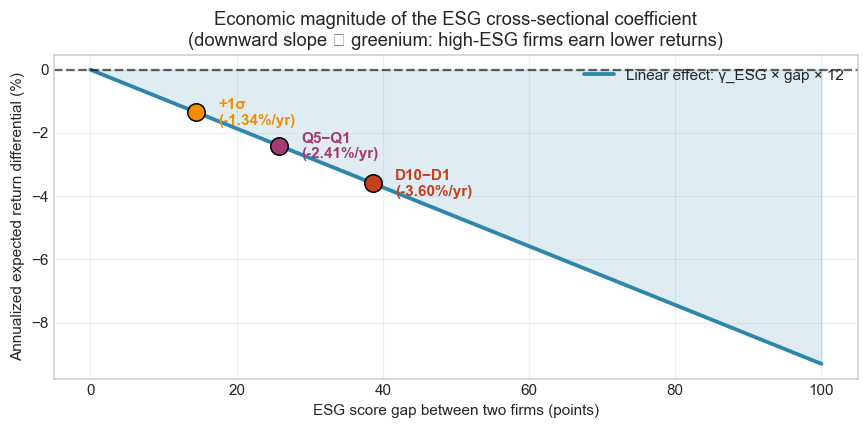

In [129]:
# Plot: greenium curve as a function of ESG gap
gaps = np.linspace(0, 100, 200)
ann_impact = gaps * g_esg * 12 * 100  # in %

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gaps, ann_impact, color='#2E86AB', linewidth=2.5,
        label=f'Linear effect: γ_ESG × gap × 12')
ax.fill_between(gaps, ann_impact, 0,
                where=(ann_impact <= 0), color='#2E86AB', alpha=0.15)
ax.axhline(0, color='black', linestyle='--', alpha=0.6)

# Mark the key scenarios on the curve
markers = [(esg_std,   '+1σ',                '#F18F01'),
           (gap_quint, 'Q5−Q1',              '#A23B72'),
           (gap_dec,   'D10−D1',             '#C73E1D')]
for x, label, col in markers:
    y = x * g_esg * 12 * 100
    ax.scatter([x], [y], s=130, color=col, zorder=5, edgecolor='black')
    ax.annotate(f'{label}\n({y:+.2f}%/yr)',
                xy=(x, y), xytext=(x+3, y-0.4),
                fontsize=10, color=col, fontweight='bold')

ax.set_xlabel('ESG score gap between two firms (points)')
ax.set_ylabel('Annualized expected return differential (%)')
ax.set_title('Economic magnitude of the ESG cross-sectional coefficient\n'
             '(downward slope ⇒ greenium: high-ESG firms earn lower returns)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('FM_ESG_economic_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

In [130]:
# Cross-check with the long-short portfolio result from your other notebook
print("\n" + "="*78)
print("METHODOLOGICAL CROSS-CHECK")
print("="*78)
print(f"""
Greenium implied by Fama-MacBeth for a top-bottom quintile gap
  ({gap_quint:.1f} ESG points, averaged over the sample):

      {gap_quint * g_esg * 12 * 100:+.2f}% per year

→ This should be close (in absolute value, opposite sign) to the alpha of
  your long-short quintile portfolio (Top ESG − Bottom ESG) from the
  ESG_FamaFrench_Regression notebook.

  If LS_Quintile alpha ≈ {-gap_quint * g_esg * 12 * 100:+.2f}%, both methods agree
  → strong evidence that the greenium is real and not a methodological artifact.
""")


METHODOLOGICAL CROSS-CHECK

Greenium implied by Fama-MacBeth for a top-bottom quintile gap
  (25.8 ESG points, averaged over the sample):

      -2.41% per year

→ This should be close (in absolute value, opposite sign) to the alpha of
  your long-short quintile portfolio (Top ESG − Bottom ESG) from the
  ESG_FamaFrench_Regression notebook.

  If LS_Quintile alpha ≈ +2.41%, both methods agree
  → strong evidence that the greenium is real and not a methodological artifact.

